C:\Users\User\AppData\Local\Temp\ipykernel_23908\315450300.py:6: DtypeWarning: Columns (0: medal) have mixed types. Specify dtype option on import or set low_memory=False.
  df_results = pd.read_csv('../../raw/world_olympedia_olympics_athlete_event_result.csv')


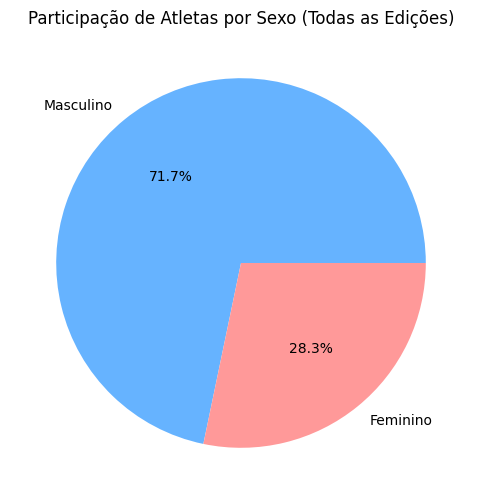

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Ler dados brutos
df_bio = pd.read_csv('../../raw/world_olympedia_olympics_athlete_bio.csv')
df_results = pd.read_csv('../../raw/world_olympedia_olympics_athlete_event_result.csv')
df_paris = pd.read_csv('../../raw/athletes.csv')

# Histórico: JOIN bio e results para obter (Nome, Sexo, Edição)
df_hist = pd.merge(df_results[['athlete_id', 'edition']], df_bio[['athlete_id', 'name', 'sex']], on='athlete_id', how='left')
df_hist = df_hist[['name', 'sex', 'edition']].drop_duplicates()

# 3. Paris: Padronizar colunas para bater com o histórico
df_paris_clean = df_paris[['name', 'gender']].rename(columns={'gender': 'sex'})
df_paris_clean['edition'] = '2024 Summer Olympics'

# Consolidar e Salvar em Parquet (BRONZE)
df_genero = pd.concat([df_hist, df_paris_clean], ignore_index=True)
df_genero['sex'] = df_genero['sex'].replace({'Male': 'Masculino', 'Female': 'Feminino'})
df_genero.to_parquet('../../bronze/atletas_por_sexo.parquet', index=False)

# Gerar Sumário e Gráfico (GOLD)
df_gold_genero = df_genero['sex'].value_counts().reset_index()
df_gold_genero.columns = ['Sexo', 'Total_Participacoes']
df_gold_genero.to_csv('genero_summary.csv', index=False)

plt.figure(figsize=(8, 6))
plt.pie(df_gold_genero['Total_Participacoes'], labels=df_gold_genero['Sexo'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Participação de Atletas por Sexo (Todas as Edições)')
plt.savefig('genero_plot.png')
plt.show()